# Mini-Project 1 — Advanced Python Data Exploration & Automated Reporting

**Dataset:** Sample - Superstore 2019.xls
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn
**Prepared for:** Data Analysis Course — Mini-Project 1


## Business Objective

A multinational retail company wants an automated analytical solution to
monitor **sales**, **profitability**, **customer behavior**, and
**operational performance** (shipping).

In this notebook we will:

- Load and inspect the Superstore dataset
- Clean the data and make it consistent
- Create a few new useful columns (feature engineering)
- Explore the data and answer business questions
- Run basic statistical analysis (correlation, distribution, trend)
- Build clear visualizations
- Generate an automated KPI summary and a short business report
- Export the cleaned data, the report, and the charts automatically
- Summarize the main business conclusions


## 3. Import Libraries

We import the basic libraries needed for this project: Pandas and NumPy
for data handling, and Matplotlib/Seaborn for visualizations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Nicer default look for the charts
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Libraries imported successfully.")


Libraries imported successfully.


## 4. Load Dataset

We load the Excel file using Pandas. We use a `try/except` block so that,
if the file is missing or cannot be read, the program prints a clear
message instead of crashing.

In [15]:
file_path = "E:\DEPI\Tech\MINI_PROJECT_1_PYHTON_Ziad_Bahaa\MINI_PROJECT_1_PYTHON_Ziad_Bahaa\GITHUB\Superstore-Sales-Analysis\data\Sample - Superstore 2019.xls"
try:
    df = pd.read_excel(file_path, sheet_name="Orders")
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Dataset file was not found. Please check the file path.")
except Exception as e:
    print("An error occurred while loading the dataset:", e)


<>:1: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:1: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
C:\Users\DrZiad\AppData\Local\Temp\ipykernel_14292\2663661501.py:1: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  file_path = "E:\DEPI\Tech\MINI_PROJECT_1_PYHTON_Ziad_Bahaa\MINI_PROJECT_1_PYTHON_Ziad_Bahaa\GITHUB\Superstore-Sales-Analysis\data\Sample - Superstore 2019.xls"


Dataset loaded successfully.


## 5. Dataset Inspection

Before doing anything else, we take a first look at the raw dataset.
We do **not** change any data in this section — we only inspect it.

In [16]:
# First 5 rows
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [17]:
# Last 5 rows
df.tail()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2016-110422,2016-01-21,2016-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180.0,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2019-121258,2019-02-26,2019-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627.0,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2019-121258,2019-02-26,2019-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627.0,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2019-121258,2019-02-26,2019-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627.0,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2019-119914,2019-05-04,2019-05-09,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683.0,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


In [18]:
# Number of rows and columns
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])


Number of rows: 9994
Number of columns: 21


In [19]:
# Column names
df.columns.tolist()


['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country/Region',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

In [7]:
# Data types of each column
df.dtypes


Row ID                     int64
Order ID                     str
Order Date        datetime64[us]
Ship Date         datetime64[us]
Ship Mode                    str
Customer ID                  str
Customer Name                str
Segment                      str
Country/Region               str
City                         str
State                        str
Postal Code              float64
Region                       str
Product ID                   str
Category                     str
Sub-Category                 str
Product Name                 str
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
dtype: object

In [8]:
# General information about the dataset
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          9994 non-null   int64         
 1   Order ID        9994 non-null   str           
 2   Order Date      9994 non-null   datetime64[us]
 3   Ship Date       9994 non-null   datetime64[us]
 4   Ship Mode       9994 non-null   str           
 5   Customer ID     9994 non-null   str           
 6   Customer Name   9994 non-null   str           
 7   Segment         9994 non-null   str           
 8   Country/Region  9994 non-null   str           
 9   City            9994 non-null   str           
 10  State           9994 non-null   str           
 11  Postal Code     9983 non-null   float64       
 12  Region          9994 non-null   str           
 13  Product ID      9994 non-null   str           
 14  Category        9994 non-null   str           
 15  Sub-Category   

In [9]:
# Descriptive statistics of numeric columns
df.describe()


,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9983.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2018-04-30 10:03:51.979187,2018-05-04 09:03:29.645787,55245.233297,229.858001,3.789574,0.156203,28.656896
min,1.000000,2016-01-03 00:00:00,2016-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2017-05-23 00:00:00,2017-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2018-06-26 00:00:00,2018-06-29 00:00:00,57103.000000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2019-05-14 00:00:00,2019-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2019-12-30 00:00:00,2020-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32038.715955,623.245101,2.225110,0.206452,234.260108


In [10]:
# Check missing values in each column
df.isnull().sum()


Row ID             0
Order ID           0
Order Date         0
Ship Date          0
Ship Mode          0
Customer ID        0
Customer Name      0
Segment            0
Country/Region     0
City               0
State              0
Postal Code       11
Region             0
Product ID         0
Category           0
Sub-Category       0
Product Name       0
Sales              0
Quantity           0
Discount           0
Profit             0
dtype: int64

In [11]:
# Check number of duplicated rows
print("Number of duplicated rows:", df.duplicated().sum())


Number of duplicated rows: 0


In [12]:
# Number of unique values in each column
df.nunique()


Row ID            9994
Order ID          5009
Order Date        1236
Ship Date         1334
Ship Mode            4
Customer ID        793
Customer Name      793
Segment              3
Country/Region       1
City               531
State               49
Postal Code        630
Region               4
Product ID        1862
Category             3
Sub-Category        17
Product Name      1850
Sales             6144
Quantity            14
Discount            12
Profit            7545
dtype: int64

**Interpretation:** The dataset has **9,994 rows** and **21 columns**.
Most columns have no missing values, except for `Postal Code`, which has a
small number of missing values. There are no fully duplicated rows in the
raw data, but we will still check again after cleaning to be safe.

## 6. Data Cleaning

Now we clean the dataset step by step: missing values, duplicates, data
types, inconsistent text formats, and outliers.

### 6.1 Missing Values

We already saw that `Postal Code` has a few missing values. Since
`Postal Code` is just an identifier (not used in our numeric analysis),
we fill missing postal codes with `0` as a simple placeholder, so we do
not lose any rows of real sales data.

In [13]:
print("Missing values BEFORE cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])

df["Postal Code"] = df["Postal Code"].fillna(0)

print()
print("Missing values AFTER cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0] if df.isnull().sum().sum() > 0 else "No missing values remaining.")


Missing values BEFORE cleaning:
Postal Code    11
dtype: int64

Missing values AFTER cleaning:
No missing values remaining.


### 6.2 Duplicate Records

We check again for duplicated rows and remove them if any exist.

In [14]:
duplicates_before = df.duplicated().sum()
print("Number of duplicate rows BEFORE removing:", duplicates_before)

df = df.drop_duplicates()

duplicates_after = df.duplicated().sum()
print("Number of duplicate rows AFTER removing:", duplicates_after)
print("New shape of the dataset:", df.shape)


Number of duplicate rows BEFORE removing: 0
Number of duplicate rows AFTER removing: 0
New shape of the dataset: (9994, 21)


### 6.3 Data Types

We make sure the important columns have the correct data type:
`Order Date` and `Ship Date` should be datetime, and `Sales`, `Quantity`,
`Discount`, and `Profit` should be numeric.

In [15]:
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], errors="coerce")

df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["Discount"] = pd.to_numeric(df["Discount"], errors="coerce")
df["Profit"] = pd.to_numeric(df["Profit"], errors="coerce")

df[["Order Date", "Ship Date", "Sales", "Quantity", "Discount", "Profit"]].dtypes


Order Date    datetime64[us]
Ship Date     datetime64[us]
Sales                float64
Quantity               int64
Discount             float64
Profit               float64
dtype: object

### 6.4 Inconsistent Formats

We clean the important text (categorical) columns by removing extra
spaces and checking that category names are consistent (for example,
no `"west"` and `"West "` being treated as two different values).

In [16]:
text_columns = ["Ship Mode", "Segment", "Region", "Category", "Sub-Category"]

for col in text_columns:
    df[col] = df[col].astype(str).str.strip()

# Check the unique values to confirm they are now consistent
for col in text_columns:
    print(col, "->", df[col].unique())


Ship Mode -> <StringArray>
['Second Class', 'Standard Class', 'First Class', 'Same Day']
Length: 4, dtype: str
Segment -> <StringArray>
['Consumer', 'Corporate', 'Home Office']
Length: 3, dtype: str
Region -> <StringArray>
['South', 'West', 'Central', 'East']
Length: 4, dtype: str
Category -> <StringArray>
['Furniture', 'Office Supplies', 'Technology']
Length: 3, dtype: str
Sub-Category -> <StringArray>
[  'Bookcases',      'Chairs',      'Labels',      'Tables',     'Storage',
 'Furnishings',         'Art',      'Phones',     'Binders',  'Appliances',
       'Paper', 'Accessories',   'Envelopes',   'Fasteners',    'Supplies',
    'Machines',     'Copiers']
Length: 17, dtype: str


### 6.5 Outliers

We check for outliers in `Sales`, `Profit`, `Quantity`, and `Discount`
using the **IQR (Interquartile Range) method**. A value is considered an
outlier if it falls below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR`.

We only **detect** the outliers here — we do **not** remove them
automatically, because some very high Sales or Profit values may
represent real, large business orders rather than data errors.

In [17]:
def count_outliers_iqr(data, column):
    """
    Count how many values in a numeric column are outliers,
    using the IQR (Interquartile Range) method.
    """
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers)


for col in ["Sales", "Profit", "Quantity", "Discount"]:
    outlier_count = count_outliers_iqr(df, col)
    print(f"{col}: {outlier_count} possible outliers detected")


Sales: 1167 possible outliers detected


Profit: 1881 possible outliers detected
Quantity: 170 possible outliers detected
Discount: 856 possible outliers detected


**Decision on outliers:** We choose to **keep** the outliers in the
dataset. Very high `Sales` or `Profit` values likely represent large,
legitimate customer orders, and removing them could hide important
business information (for example, our best customers or best-selling
products). We will simply keep this in mind when interpreting charts
such as histograms and boxplots.

## 7. Reusable Preprocessing Functions

To make our cleaning steps reusable on new data in the future, we wrap
the main cleaning steps into simple functions. Each function does one
clear job.

In [18]:
def clean_column_names(data):
    """Remove extra spaces from column names (keeps the names themselves unchanged)."""
    data = data.copy()
    data.columns = [col.strip() for col in data.columns]
    return data


def handle_missing_values(data):
    """Fill missing Postal Code values with 0, since it is just an identifier."""
    data = data.copy()
    if "Postal Code" in data.columns:
        data["Postal Code"] = data["Postal Code"].fillna(0)
    return data


def remove_duplicates(data):
    """Remove fully duplicated rows from the dataset."""
    data = data.copy()
    data = data.drop_duplicates()
    return data


def convert_data_types(data):
    """Convert date columns to datetime and key numeric columns to numeric type."""
    data = data.copy()
    data["Order Date"] = pd.to_datetime(data["Order Date"], errors="coerce")
    data["Ship Date"] = pd.to_datetime(data["Ship Date"], errors="coerce")
    for col in ["Sales", "Quantity", "Discount", "Profit"]:
        data[col] = pd.to_numeric(data[col], errors="coerce")
    return data


def clean_text_columns(data, columns):
    """Strip extra spaces from the given text columns."""
    data = data.copy()
    for col in columns:
        data[col] = data[col].astype(str).str.strip()
    return data


In [19]:
# Demonstrate the reusable preprocessing workflow on a fresh copy of the raw data
raw_df = pd.read_excel(file_path, sheet_name="Orders")

cleaned_df = clean_column_names(raw_df)
cleaned_df = handle_missing_values(cleaned_df)
cleaned_df = remove_duplicates(cleaned_df)
cleaned_df = convert_data_types(cleaned_df)
cleaned_df = clean_text_columns(cleaned_df, ["Ship Mode", "Segment", "Region", "Category", "Sub-Category"])

print("Preprocessing workflow completed.")
print("Shape of cleaned_df:", cleaned_df.shape)

# From here on, we continue working with cleaned_df as our main dataframe
df = cleaned_df
df.head()


Preprocessing workflow completed.
Shape of cleaned_df: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## 8. Feature Engineering

We create three new columns that will help us analyze the business
performance more deeply: **Profit Margin**, **Shipping Duration**, and
**Sales Performance Category**.

### 8.1 Profit Margin

Profit Margin shows what percentage of each sale turned into profit:

`Profit Margin = (Profit / Sales) * 100`

We handle the case where `Sales` is 0 to avoid a division-by-zero error.

In [20]:
df["Profit Margin"] = np.where(df["Sales"] != 0, (df["Profit"] / df["Sales"]) * 100, 0)

df[["Sales", "Profit", "Profit Margin"]].head()


,Sales,Profit,Profit Margin
0,261.9600,41.9136,16.00
1,731.9400,219.5820,30.00
2,14.6200,6.8714,47.00
3,957.5775,-383.0310,-40.00
4,22.3680,2.5164,11.25


### 8.2 Shipping Duration

Shipping Duration is the number of days between the order date and the
ship date. This tells us how fast orders were shipped.

In [21]:
df["Shipping Duration"] = (df["Ship Date"] - df["Order Date"]).dt.days

df[["Order Date", "Ship Date", "Shipping Duration"]].head()


,Order Date,Ship Date,Shipping Duration
0,2018-11-08,2018-11-11,3
1,2018-11-08,2018-11-11,3
2,2018-06-12,2018-06-16,4
3,2017-10-11,2017-10-18,7
4,2017-10-11,2017-10-18,7


### 8.3 Sales Performance Category

We split `Sales` into three simple groups — **Low**, **Medium**, and
**High** — using `pd.cut()`. We choose the cut points based on the
33rd and 66th percentile of the actual `Sales` values, so the thresholds
reflect this specific dataset.

In [22]:
low_cut = df["Sales"].quantile(0.33)
high_cut = df["Sales"].quantile(0.66)

print(f"Low / Medium boundary: {low_cut:.2f}")
print(f"Medium / High boundary: {high_cut:.2f}")

df["Sales Performance Category"] = pd.cut(
    df["Sales"],
    bins=[-np.inf, low_cut, high_cut, np.inf],
    labels=["Low", "Medium", "High"]
)

df["Sales Performance Category"].value_counts()


Low / Medium boundary: 24.87
Medium / High boundary: 122.95


Sales Performance Category
High      3398
Low       3298
Medium    3298
Name: count, dtype: int64

## 9. Object-Oriented Programming (OOP)

We create one simple class, `SuperstoreAnalyzer`, that groups together a
few basic analysis methods. This demonstrates the OOP requirement in a
simple way — one class, a few clear methods.

In [23]:
class SuperstoreAnalyzer:
    """A simple class that stores the dataframe and provides basic analysis methods."""

    def __init__(self, data):
        self.df = data

    def calculate_kpis(self):
        """Return a dictionary with a few key business numbers."""
        total_sales = self.df["Sales"].sum()
        total_profit = self.df["Profit"].sum()
        overall_margin = (total_profit / total_sales) * 100

        kpis = {
            "Total Sales": total_sales,
            "Total Profit": total_profit,
            "Overall Profit Margin (%)": overall_margin,
        }
        return kpis

    def sales_by_category(self):
        """Return total sales grouped by Category."""
        return self.df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

    def profit_by_region(self):
        """Return total profit grouped by Region."""
        return self.df.groupby("Region")["Profit"].sum().sort_values(ascending=False)


In [24]:
# Create an object of the class
analyzer = SuperstoreAnalyzer(df)

# Use its methods
print("KPIs from the analyzer object:")
print(analyzer.calculate_kpis())

print()
print("Sales by Category:")
print(analyzer.sales_by_category())

print()
print("Profit by Region:")
print(analyzer.profit_by_region())


KPIs from the analyzer object:
{'Total Sales': np.float64(2297200.8603), 'Total Profit': np.float64(286397.0216999999), 'Overall Profit Margin (%)': np.float64(12.467217240315604)}

Sales by Category:
Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

Profit by Region:
Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


## 10. Exploratory Data Analysis (EDA)

In this section we answer several business questions about sales,
profit, customers, products, and shipping. To keep the code organized,
we write a simple, separate function for each analysis area.

In [25]:
def sales_analysis(data):
    """Return a dictionary with the main sales results."""
    results = {
        "total_sales": data["Sales"].sum(),
        "average_sales": data["Sales"].mean(),
        "sales_by_category": data.groupby("Category")["Sales"].sum().sort_values(ascending=False),
        "sales_by_region": data.groupby("Region")["Sales"].sum().sort_values(ascending=False),
        "sales_by_segment": data.groupby("Segment")["Sales"].sum().sort_values(ascending=False),
    }
    return results


def profit_analysis(data):
    """Return a dictionary with the main profit results."""
    results = {
        "total_profit": data["Profit"].sum(),
        "average_profit": data["Profit"].mean(),
        "profit_by_category": data.groupby("Category")["Profit"].sum().sort_values(ascending=False),
        "profit_by_region": data.groupby("Region")["Profit"].sum().sort_values(ascending=False),
    }
    return results


def customer_analysis(data):
    """Return a dictionary with the main customer results."""
    results = {
        "unique_customers": data["Customer ID"].nunique(),
        "top_customers_by_sales": data.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10),
        "top_customers_by_profit": data.groupby("Customer Name")["Profit"].sum().sort_values(ascending=False).head(10),
    }
    return results


def shipping_analysis(data):
    """Return a dictionary with the main shipping results."""
    results = {
        "average_shipping_duration": data["Shipping Duration"].mean(),
        "shipping_duration_by_mode": data.groupby("Ship Mode")["Shipping Duration"].mean().sort_values(),
    }
    return results


### 10.1 Sales Analysis

In [26]:
sales_results = sales_analysis(df)

print(f"Total Sales: ${sales_results['total_sales']:,.2f}")
print(f"Average Sales per order line: ${sales_results['average_sales']:,.2f}")
print()
print("Sales by Category:")
print(sales_results["sales_by_category"])
print()
print("Sales by Region:")
print(sales_results["sales_by_region"])
print()
print("Sales by Segment:")
print(sales_results["sales_by_segment"])


Total Sales: $2,297,200.86
Average Sales per order line: $229.86

Sales by Category:
Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

Sales by Region:
Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

Sales by Segment:
Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64


**Interpretation:** The category with the highest total sales is shown
at the top of the `sales_by_category` list above. This tells the company
which product category customers buy the most.

### 10.2 Profit Analysis

In [27]:
profit_results = profit_analysis(df)

print(f"Total Profit: ${profit_results['total_profit']:,.2f}")
print(f"Average Profit per order line: ${profit_results['average_profit']:,.2f}")
print()
print("Profit by Category:")
print(profit_results["profit_by_category"])
print()
print("Profit by Region:")
print(profit_results["profit_by_region"])


Total Profit: $286,397.02
Average Profit per order line: $28.66

Profit by Category:
Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

Profit by Region:
Region
West       108418.4489
East        91522.7800
South       46749.4303
Central     39706.3625
Name: Profit, dtype: float64


**Interpretation:** A category can have high sales but still generate
lower profit, if its profit margin is small. We compare this list with
the sales list above to see if the best-selling category is also the
most profitable one.

### 10.3 Monthly Sales and Profit Trend

In [28]:
df["Order Month"] = df["Order Date"].dt.to_period("M")

monthly_sales = df.groupby("Order Month")["Sales"].sum()
monthly_profit = df.groupby("Order Month")["Profit"].sum()

print("Monthly Sales (first 5 months):")
print(monthly_sales.head())
print()
print("Monthly Profit (first 5 months):")
print(monthly_profit.head())


Monthly Sales (first 5 months):
Order Month
2016-01    14236.895
2016-02     4519.892
2016-03    55691.009
2016-04    28295.345
2016-05    23648.287
Freq: M, Name: Sales, dtype: float64

Monthly Profit (first 5 months):
Order Month
2016-01    2450.1907
2016-02     862.3084
2016-03     498.7299
2016-04    3488.8352
2016-05    2738.7096
Freq: M, Name: Profit, dtype: float64


**Interpretation:** Looking at monthly totals lets us see whether sales
and profit are growing over time, or if there are seasonal patterns
(for example, higher sales near the end of the year).

### 10.4 Customer Analysis

In [29]:
customer_results = customer_analysis(df)

print("Number of unique customers:", customer_results["unique_customers"])
print()
print("Top 10 customers by Sales:")
print(customer_results["top_customers_by_sales"])
print()
print("Top 10 customers by Profit:")
print(customer_results["top_customers_by_profit"])


Number of unique customers: 793

Top 10 customers by Sales:
Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

Top 10 customers by Profit:
Customer Name
Tamara Chand            8981.3239
Raymond Buch            6976.0959
Sanjit Chand            5757.4119
Hunter Lopez            5622.4292
Adrian Barton           5444.8055
Tom Ashbrook            4703.7883
Christopher Martinez    3899.8904
Keith Dawkins           3038.6254
Andy Reiter             2884.6208
Daniel Raglin           2869.0760
Name: Profit, dtype: float64


**Interpretation:** These top customers generate a large share of the
company's revenue and profit, so they could be good targets for loyalty
programs or special offers.

### 10.5 Product Analysis

In [31]:
top_products_sales = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)
top_products_profit = df.groupby("Product Name")["Profit"].sum().sort_values(ascending=False).head(10)
negative_profit_products = df[df["Profit"] < 0].groupby("Product Name")["Profit"].sum().sort_values().head(10)

print("Top 10 Products by Sales:")
print(top_products_sales)
print()
print("Top 10 Products by Profit:")
print(top_products_profit)
print()
print("Top 10 Products with the most negative Profit (biggest losses):")
print(negative_profit_products)


Top 10 Products by Sales:
Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

Top 10 Products by Profit:
Product Name
Ca

**Interpretation:** Some products are sold often but still lose money
(negative profit). The company may want to review the pricing or
discount policy for these specific products.

### 10.6 Shipping Analysis

In [32]:
shipping_results = shipping_analysis(df)

print(f"Average Shipping Duration: {shipping_results['average_shipping_duration']:.2f} days")
print()
print("Average Shipping Duration by Ship Mode:")
print(shipping_results["shipping_duration_by_mode"])


Average Shipping Duration: 3.96 days

Average Shipping Duration by Ship Mode:
Ship Mode
Same Day          0.044199
First Class       2.182705
Second Class      3.237532
Standard Class    5.006535
Name: Shipping Duration, dtype: float64


**Interpretation:** As expected, faster shipping modes (like
`Same Day` or `First Class`) should have a shorter average shipping
duration than slower ones (like `Standard Class`).

## 11. Statistical Analysis

Here we look at descriptive statistics, correlation between numeric
variables, the shape of important distributions, and trends over time.

### 11.1 Descriptive Statistics

In [33]:
df[["Sales", "Profit", "Discount", "Quantity", "Profit Margin", "Shipping Duration"]].describe()


,Sales,Profit,Discount,Quantity,Profit Margin,Shipping Duration
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,229.858001,28.656896,0.156203,3.789574,12.031393,3.958075
std,623.245101,234.260108,0.206452,2.225110,46.675435,1.747937
min,0.444000,-6599.978000,0.000000,1.000000,-275.000000,0.000000
25%,17.280000,1.728750,0.000000,2.000000,7.500000,3.000000
50%,54.490000,8.666500,0.200000,3.000000,27.000000,4.000000
75%,209.940000,29.364000,0.200000,5.000000,36.250000,5.000000
max,22638.480000,8399.976000,0.800000,14.000000,50.000000,7.000000


**Interpretation:** The `describe()` table shows the mean, standard
deviation, minimum, and maximum of each numeric column. A big difference
between the mean and the maximum (for example, in `Sales` or `Profit`)
confirms what we already found: there are some very large orders in the
data.

### 11.2 Correlation Analysis

We calculate the Pearson correlation between the main numeric columns.
Correlation values range from -1 to 1: values close to 1 mean a strong
positive relationship, values close to -1 mean a strong negative
relationship, and values close to 0 mean little to no linear
relationship.

In [34]:
numeric_columns = ["Sales", "Quantity", "Discount", "Profit", "Shipping Duration", "Profit Margin"]
correlation_matrix = df[numeric_columns].corr(numeric_only=True)
correlation_matrix


,Sales,Quantity,Discount,Profit,Shipping Duration,Profit Margin
Sales,1.000000,0.200795,-0.028190,0.479064,-0.007350,0.003444
Quantity,0.200795,1.000000,0.008623,0.066253,0.018315,-0.005280
Discount,-0.028190,0.008623,1.000000,-0.219487,0.000452,-0.864452
Profit,0.479064,0.066253,-0.219487,1.000000,-0.004658,0.223732
Shipping Duration,-0.007350,0.018315,0.000452,-0.004658,1.000000,-0.011800
Profit Margin,0.003444,-0.005280,-0.864452,0.223732,-0.011800,1.000000


**Interpretation:** We look for the strongest positive and negative
values in the table above (ignoring the diagonal, which is always 1).
For example, if `Discount` and `Profit` show a negative correlation,
this indicates that higher discounts are **associated with** lower
profit in this dataset — this does **not** prove that discounts directly
cause lower profit, only that they tend to move in opposite directions
together.

### 11.3 Distribution Analysis

We look at the shape of the distribution for `Sales`, `Profit`,
`Discount`, and `Quantity` using their descriptive statistics (the
actual histograms are shown in the Visualizations section below).

In [35]:
for col in ["Sales", "Profit", "Discount", "Quantity"]:
    print(f"--- {col} ---")
    print(f"Mean:   {df[col].mean():.2f}")
    print(f"Median: {df[col].median():.2f}")
    print(f"Std:    {df[col].std():.2f}")
    print()


--- Sales ---
Mean:   229.86
Median: 54.49
Std:    623.25

--- Profit ---
Mean:   28.66
Median: 8.67
Std:    234.26

--- Discount ---
Mean:   0.16
Median: 0.20
Std:    0.21

--- Quantity ---
Mean:   3.79
Median: 3.00
Std:    2.23



**Interpretation:** When the mean is quite different from the median,
this usually means the distribution is skewed (not symmetric), often
because of a small number of very high values.

### 11.4 Trend Analysis

We already calculated `monthly_sales` and `monthly_profit` in the EDA
section. We will visualize these trends as line charts in the next
section.

## 12. Data Visualizations

We now create the required charts. Every chart is saved automatically
into a `visualizations/` folder, which is created if it does not
already exist.

In [36]:
VISUALS_FOLDER = "visualizations"
os.makedirs(VISUALS_FOLDER, exist_ok=True)

def save_chart(fig, filename):
    """Save a chart into the visualizations folder and then show it."""
    path = os.path.join(VISUALS_FOLDER, filename)
    fig.savefig(path, bbox_inches="tight", dpi=100)
    print("Saved:", path)
    plt.show()


Saved: visualizations\01_sales_distribution.png


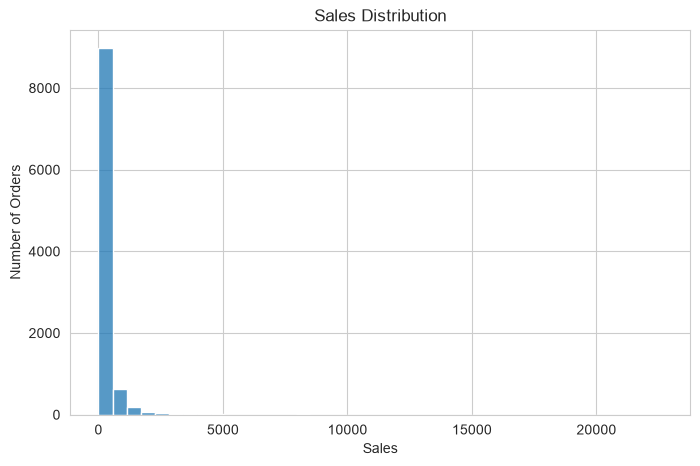

In [37]:
# 1. Sales Distribution - Histogram
fig, ax = plt.subplots()
sns.histplot(df["Sales"], bins=40, ax=ax)
ax.set_title("Sales Distribution")
ax.set_xlabel("Sales")
ax.set_ylabel("Number of Orders")
save_chart(fig, "01_sales_distribution.png")


Saved: visualizations\02_profit_distribution.png


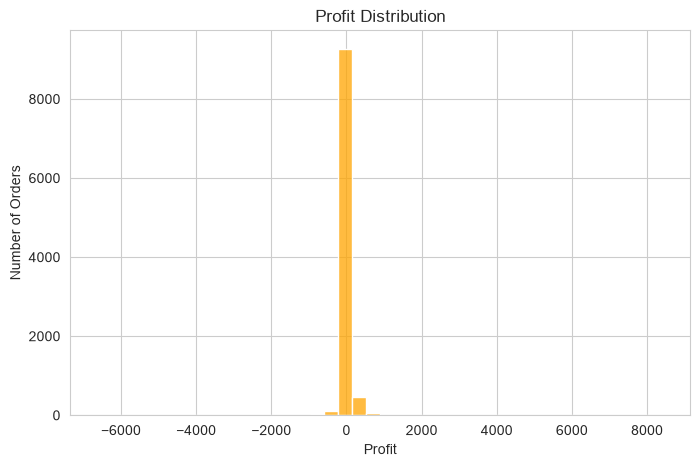

In [38]:
# 2. Profit Distribution - Histogram
fig, ax = plt.subplots()
sns.histplot(df["Profit"], bins=40, color="orange", ax=ax)
ax.set_title("Profit Distribution")
ax.set_xlabel("Profit")
ax.set_ylabel("Number of Orders")
save_chart(fig, "02_profit_distribution.png")


Saved: visualizations\03_sales_by_category.png


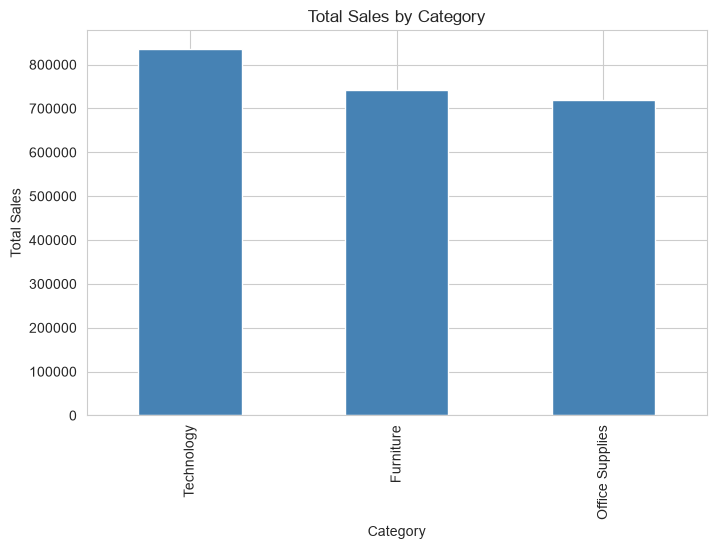

In [39]:
# 3. Sales by Category - Bar Chart
fig, ax = plt.subplots()
sales_results["sales_by_category"].plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Total Sales by Category")
ax.set_xlabel("Category")
ax.set_ylabel("Total Sales")
save_chart(fig, "03_sales_by_category.png")


Saved: visualizations\04_profit_by_category.png


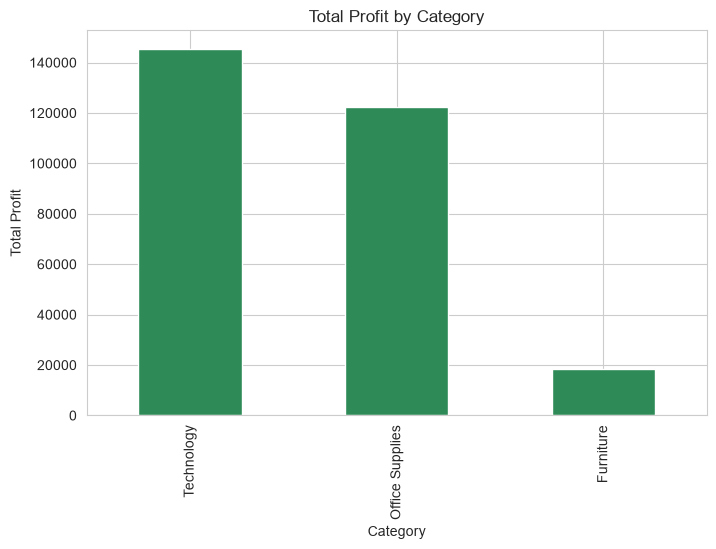

In [40]:
# 4. Profit by Category - Bar Chart
fig, ax = plt.subplots()
profit_results["profit_by_category"].plot(kind="bar", ax=ax, color="seagreen")
ax.set_title("Total Profit by Category")
ax.set_xlabel("Category")
ax.set_ylabel("Total Profit")
save_chart(fig, "04_profit_by_category.png")


Saved: visualizations\05_sales_by_region.png


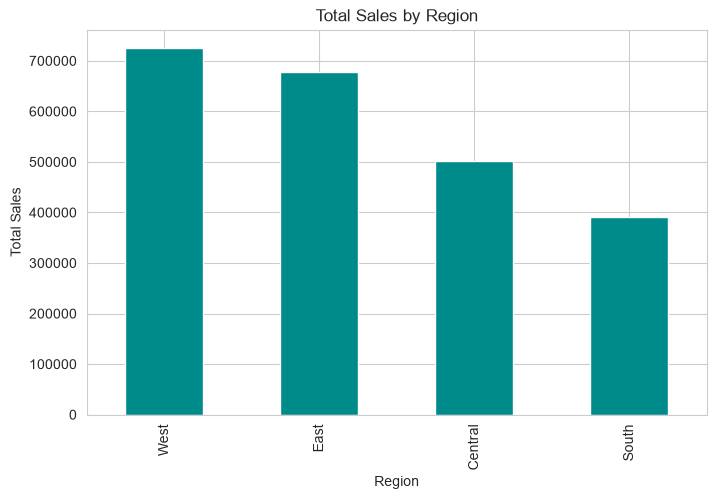

In [41]:
# 5. Sales by Region - Bar Chart
fig, ax = plt.subplots()
sales_results["sales_by_region"].plot(kind="bar", ax=ax, color="darkcyan")
ax.set_title("Total Sales by Region")
ax.set_xlabel("Region")
ax.set_ylabel("Total Sales")
save_chart(fig, "05_sales_by_region.png")


Saved: visualizations\06_monthly_sales_trend.png


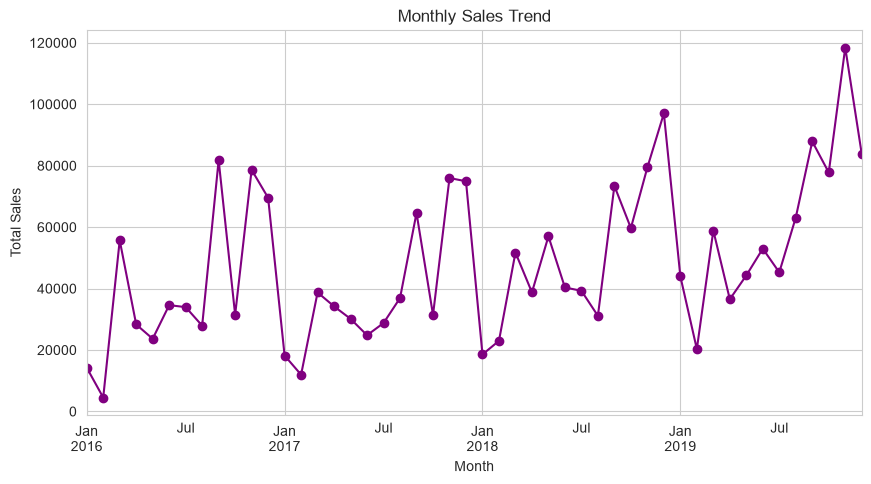

In [42]:
# 6. Monthly Sales Trend - Line Chart
fig, ax = plt.subplots(figsize=(10, 5))
monthly_sales.plot(ax=ax, marker="o", color="purple")
ax.set_title("Monthly Sales Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Total Sales")
save_chart(fig, "06_monthly_sales_trend.png")


Saved: visualizations\07_monthly_profit_trend.png


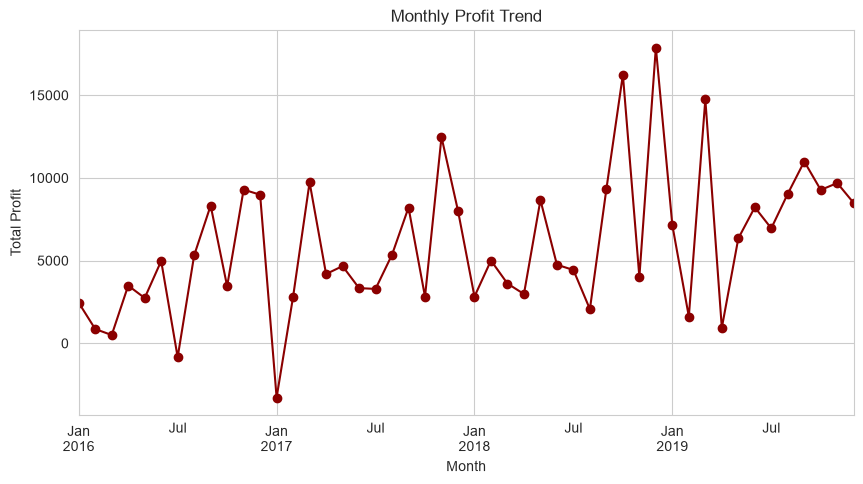

In [43]:
# 7. Monthly Profit Trend - Line Chart
fig, ax = plt.subplots(figsize=(10, 5))
monthly_profit.plot(ax=ax, marker="o", color="darkred")
ax.set_title("Monthly Profit Trend")
ax.set_xlabel("Month")
ax.set_ylabel("Total Profit")
save_chart(fig, "07_monthly_profit_trend.png")


Saved: visualizations\08_sales_vs_profit.png


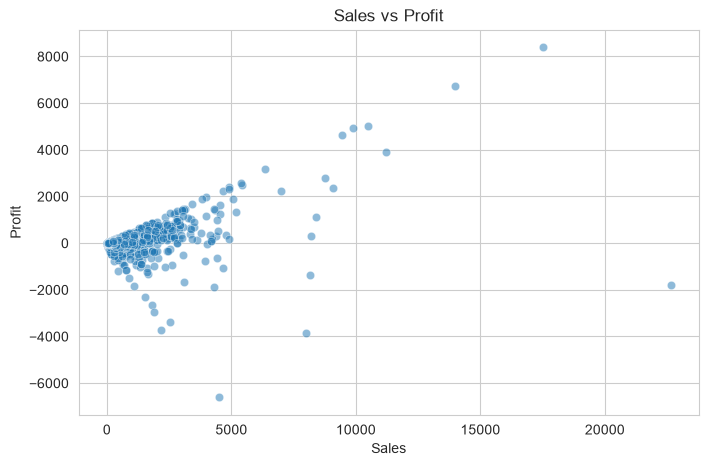

In [44]:
# 8. Sales vs Profit - Scatter Plot
fig, ax = plt.subplots()
sns.scatterplot(data=df, x="Sales", y="Profit", alpha=0.5, ax=ax)
ax.set_title("Sales vs Profit")
ax.set_xlabel("Sales")
ax.set_ylabel("Profit")
save_chart(fig, "08_sales_vs_profit.png")


Saved: visualizations\09_discount_vs_profit.png


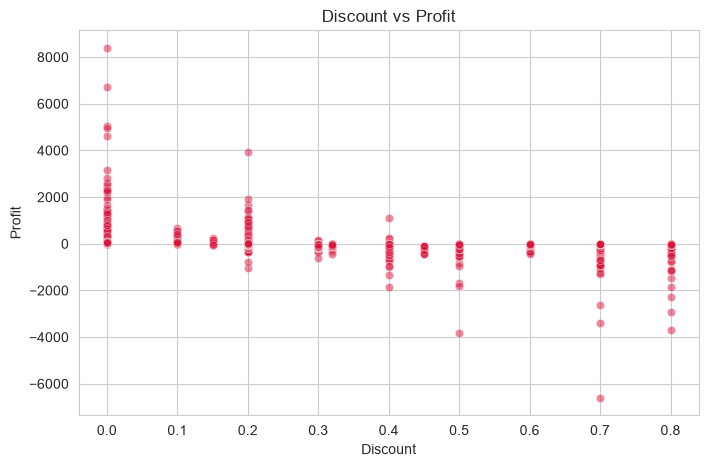

In [45]:
# 9. Discount vs Profit - Scatter Plot
fig, ax = plt.subplots()
sns.scatterplot(data=df, x="Discount", y="Profit", alpha=0.5, color="crimson", ax=ax)
ax.set_title("Discount vs Profit")
ax.set_xlabel("Discount")
ax.set_ylabel("Profit")
save_chart(fig, "09_discount_vs_profit.png")


Saved: visualizations\10_correlation_heatmap.png


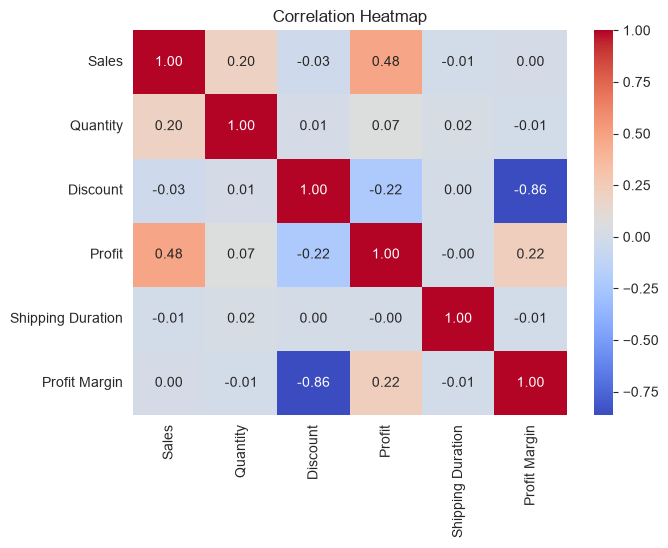

In [46]:
# 10. Correlation Heatmap
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", ax=ax)
ax.set_title("Correlation Heatmap")
save_chart(fig, "10_correlation_heatmap.png")


Saved: visualizations\11_top_products_by_sales.png


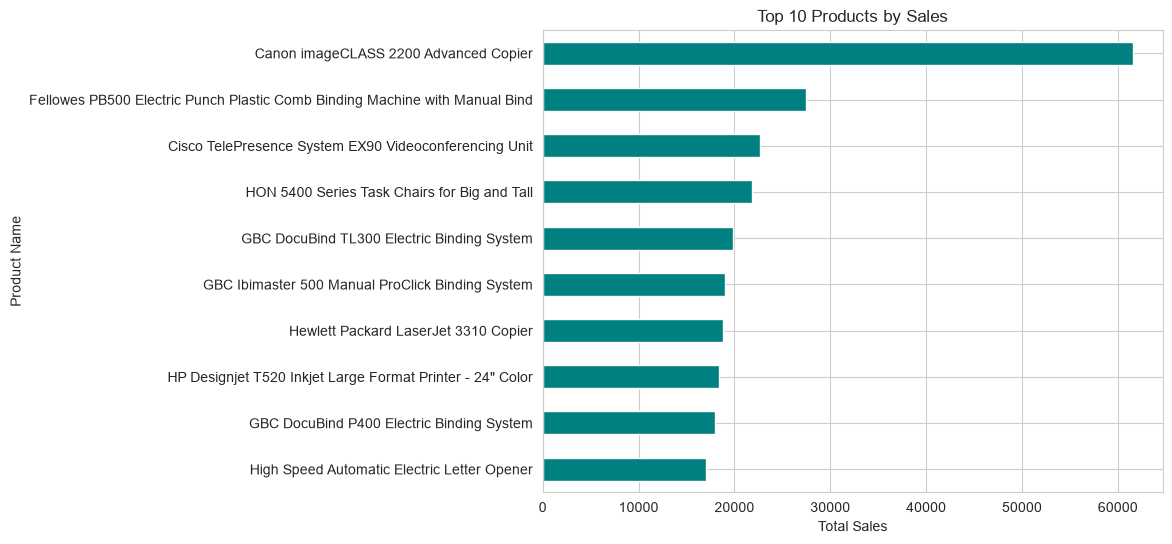

In [47]:
# 11. Top 10 Products by Sales - Bar Chart
fig, ax = plt.subplots(figsize=(8, 6))
top_products_sales.plot(kind="barh", ax=ax, color="teal")
ax.set_title("Top 10 Products by Sales")
ax.set_xlabel("Total Sales")
ax.invert_yaxis()
save_chart(fig, "11_top_products_by_sales.png")


Saved: visualizations\12_profit_by_ship_mode.png


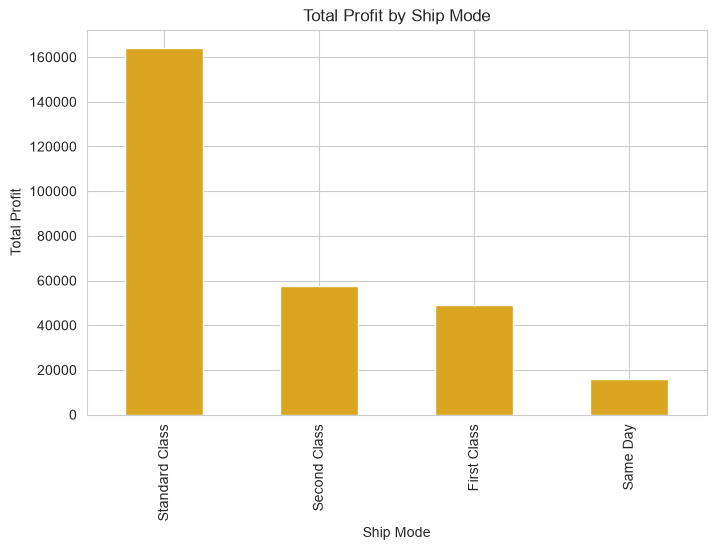

In [48]:
# 12. Profit by Ship Mode - Bar Chart
fig, ax = plt.subplots()
df.groupby("Ship Mode")["Profit"].sum().sort_values(ascending=False).plot(kind="bar", ax=ax, color="goldenrod")
ax.set_title("Total Profit by Ship Mode")
ax.set_xlabel("Ship Mode")
ax.set_ylabel("Total Profit")
save_chart(fig, "12_profit_by_ship_mode.png")


**Interpretation:** The histograms (charts 1–2) confirm that both
`Sales` and `Profit` are right-skewed, with most orders being small and a
few orders being very large. The scatter plot of `Discount` vs `Profit`
(chart 9) helps us visually confirm the correlation we found earlier —
higher discounts tend to cluster with lower or negative profit.

## 13. Automated KPI Summary

We calculate the main KPIs directly from the data (nothing is typed in
manually) and present them in a clean table.

In [49]:
def build_kpi_summary(data):
    """Calculate the main KPIs and return them as a DataFrame."""
    total_sales = data["Sales"].sum()
    total_profit = data["Profit"].sum()
    overall_margin = (total_profit / total_sales) * 100
    total_orders = data["Order ID"].nunique()
    total_customers = data["Customer ID"].nunique()
    total_products = data["Product ID"].nunique()
    average_order_value = data.groupby("Order ID")["Sales"].sum().mean()
    average_shipping_duration = data["Shipping Duration"].mean()
    average_discount = data["Discount"].mean()
    average_quantity = data["Quantity"].mean()

    kpi_summary = pd.DataFrame({
        "Metric": [
            "Total Sales",
            "Total Profit",
            "Overall Profit Margin (%)",
            "Total Orders",
            "Total Customers",
            "Total Products",
            "Average Order Value",
            "Average Shipping Duration (days)",
            "Average Discount",
            "Average Quantity",
        ],
        "Value": [
            round(total_sales, 2),
            round(total_profit, 2),
            round(overall_margin, 2),
            total_orders,
            total_customers,
            total_products,
            round(average_order_value, 2),
            round(average_shipping_duration, 2),
            round(average_discount, 2),
            round(average_quantity, 2),
        ]
    })
    return kpi_summary


kpi_summary = build_kpi_summary(df)
kpi_summary


,Metric,Value
0,Total Sales,2297200.86
1,Total Profit,286397.02
2,Overall Profit Margin (%),12.47
3,Total Orders,5009.00
4,Total Customers,793.00
5,Total Products,1862.00
6,Average Order Value,458.61
7,Average Shipping Duration (days),3.96
8,Average Discount,0.16
9,Average Quantity,3.79


## 14. Automated Analytical Report

We now build a short, automatically generated business report using the
values we already calculated. All numbers below come directly from the
dataset through Python variables, not typed manually.

In [50]:
top_category = sales_results["sales_by_category"].idxmax()
top_region = sales_results["sales_by_region"].idxmax()
top_segment = sales_results["sales_by_segment"].idxmax()
most_profitable_category = profit_results["profit_by_category"].idxmax()
best_selling_product = top_products_sales.idxmax()

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
overall_margin = (total_profit / total_sales) * 100
average_shipping_duration = df["Shipping Duration"].mean()

report_lines = []
report_lines.append("SUPERSTORE 2019 - AUTOMATED ANALYTICAL REPORT")
report_lines.append("=" * 55)
report_lines.append(f"Total Sales: ${total_sales:,.2f}")
report_lines.append(f"Total Profit: ${total_profit:,.2f}")
report_lines.append(f"Overall Profit Margin: {overall_margin:.2f}%")
report_lines.append(f"Top Category (by Sales): {top_category}")
report_lines.append(f"Top Region (by Sales): {top_region}")
report_lines.append(f"Top Segment (by Sales): {top_segment}")
report_lines.append(f"Most Profitable Category: {most_profitable_category}")
report_lines.append(f"Best-Selling Product (by Sales): {best_selling_product}")
report_lines.append(f"Average Shipping Duration: {average_shipping_duration:.2f} days")
report_lines.append("=" * 55)

analytical_report = "\n".join(report_lines)
print(analytical_report)


SUPERSTORE 2019 - AUTOMATED ANALYTICAL REPORT
Total Sales: $2,297,200.86
Total Profit: $286,397.02
Overall Profit Margin: 12.47%
Top Category (by Sales): Technology
Top Region (by Sales): West
Top Segment (by Sales): Consumer
Most Profitable Category: Technology
Best-Selling Product (by Sales): Canon imageCLASS 2200 Advanced Copier
Average Shipping Duration: 3.96 days


**Automatically generated insights:**

In [51]:
# A few simple, automatically generated insight sentences
print(f"- {top_category} is the category that generates the most sales for the company.")
print(f"- {top_region} is the region with the highest total sales.")
print(f"- {most_profitable_category} is the most profitable category overall.")
print(f"- On average, an order takes about {average_shipping_duration:.1f} days to ship.")


- Technology is the category that generates the most sales for the company.
- West is the region with the highest total sales.
- Technology is the most profitable category overall.
- On average, an order takes about 4.0 days to ship.


## 15. Performance and Memory Optimization

Columns with a small number of repeated text values (like `Category`,
`Segment`, `Region`, and `Ship Mode`) can be converted to the pandas
`category` type. This uses less memory than storing the same repeated
text over and over.

In [52]:
print("Memory usage BEFORE optimization:")
df.info(memory_usage="deep")


Memory usage BEFORE optimization:
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Row ID                      9994 non-null   int64         
 1   Order ID                    9994 non-null   str           
 2   Order Date                  9994 non-null   datetime64[us]
 3   Ship Date                   9994 non-null   datetime64[us]
 4   Ship Mode                   9994 non-null   str           
 5   Customer ID                 9994 non-null   str           
 6   Customer Name               9994 non-null   str           
 7   Segment                     9994 non-null   str           
 8   Country/Region              9994 non-null   str           
 9   City                        9994 non-null   str           
 10  State                       9994 non-null   str           
 11  Postal Code                 9983 

In [53]:
df["Category"] = df["Category"].astype("category")
df["Segment"] = df["Segment"].astype("category")
df["Region"] = df["Region"].astype("category")
df["Ship Mode"] = df["Ship Mode"].astype("category")

print("Memory usage AFTER optimization:")
df.info(memory_usage="deep")


Memory usage AFTER optimization:
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Row ID                      9994 non-null   int64         
 1   Order ID                    9994 non-null   str           
 2   Order Date                  9994 non-null   datetime64[us]
 3   Ship Date                   9994 non-null   datetime64[us]
 4   Ship Mode                   9994 non-null   category      
 5   Customer ID                 9994 non-null   str           
 6   Customer Name               9994 non-null   str           
 7   Segment                     9994 non-null   category      
 8   Country/Region              9994 non-null   str           
 9   City                        9994 non-null   str           
 10  State                       9994 non-null   str           
 11  Postal Code                 9983 n

**Note:** We also try to prefer **vectorized Pandas operations**
(like `df["Sales"].sum()` or `np.where(...)`) instead of writing manual
`for` loops over the rows. Vectorized operations are simpler to write
and run much faster on large datasets.

## 16. Export Results

Finally, we automatically save our results to disk: the cleaned
dataset, the KPI summary, and the text report. The charts were already
saved automatically into the `visualizations/` folder in Section 12.

In [54]:
OUTPUT_FOLDER = "outputs"
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

try:
    # Cleaned dataset
    cleaned_path = os.path.join(OUTPUT_FOLDER, "cleaned_superstore.csv")
    df.to_csv(cleaned_path, index=False)
    print("Cleaned dataset saved to:", cleaned_path)

    # KPI summary
    kpi_path = os.path.join(OUTPUT_FOLDER, "kpi_summary.csv")
    kpi_summary.to_csv(kpi_path, index=False)
    print("KPI summary saved to:", kpi_path)

    # Analytical report
    report_path = os.path.join(OUTPUT_FOLDER, "analytical_report.txt")
    with open(report_path, "w") as f:
        f.write(analytical_report)
    print("Analytical report saved to:", report_path)

except Exception as e:
    print("An error occurred while exporting the results:", e)


Cleaned dataset saved to: outputs\cleaned_superstore.csv
KPI summary saved to: outputs\kpi_summary.csv
Analytical report saved to: outputs\analytical_report.txt


## 17. Final Business Conclusions

Based on the analysis above, here is a summary of the most important
findings:

**Sales performance:** Sales are not evenly spread across categories,
regions, and segments — a small number of categories and regions
(shown at the top of the `sales_by_category` and `sales_by_region`
results) generate most of the revenue.

**Profitability:** The category with the highest sales is not always
the category with the highest profit, which means some categories sell
well but at a lower profit margin. A number of individual products even
show a negative profit, meaning the company loses money every time they
are sold.

**Customer behavior:** A small group of top customers is responsible for
a large share of total sales and profit. These customers could be good
candidates for loyalty programs or personalized offers.

**Product performance:** A few products drive most of the sales and
profit, while some other products consistently lose money. It may be
worth reviewing the pricing or discount strategy for the underperforming
products.

**Shipping performance:** Shipping duration differs by `Ship Mode`, as
expected — faster shipping options have shorter average shipping times.
This confirms that the shipping data is consistent and behaves as
expected.

**Discount vs. Profit relationship:** The correlation analysis showed a
negative relationship between `Discount` and `Profit`. This suggests
that offering larger discounts is associated with lower profit in this
dataset, so the company may want to review how discounts are applied,
especially for products or categories where profit is already low.

**Recommendations:**
- Focus marketing and inventory on the top-performing categories and regions.
- Review pricing and discount levels for products with negative profit.
- Consider loyalty programs for the top customers identified above.
- Investigate why certain categories have high sales but low profit margins.
